In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("tunguz/online-retail")

print("Path to dataset files:", path)
df = pd.read_csv(path + '/' + os.listdir(path)[0], encoding='latin1')
df.shape

Path to dataset files: C:\Users\steve\.cache\kagglehub\datasets\tunguz\online-retail\versions\1


(541909, 8)

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
# 주문 가격 피쳐 생성
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [6]:
# 'InvoiceDate' 컬럼을 이용하여 주중과 주말을 구분
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

# 'InvoiceDate' 컬럼 이용하여 판매 월 추출
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"].astype(str))
df["InvoiceMonth"] = df["InvoiceDate"].dt.month

C:\Users\steve\AppData\Local\Temp\ipykernel_11468\3844768752.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


## 1. 모집단과 표본 집단의 TotalPrice를 비교해 주세요.

* 데이터셋에서 무작위로 1000개의 표본을 추출하세요.
* 추출된 표본과 전체 데이터셋의 'TotalPrice'에 대해 평균과 표준편차를 비교해주세요.  
* 중심극한정리를 사용해 모집단과 표본의 차이를 설명해주세요.

--- [분석 결과] ---
1. 모집단(전체) - 평균: 17.9878, 표준편차: 378.8108
2. 표본(1000개) - 평균: 16.8321, 표준편차: 64.4673
3. 평균의 차이: 1.1557




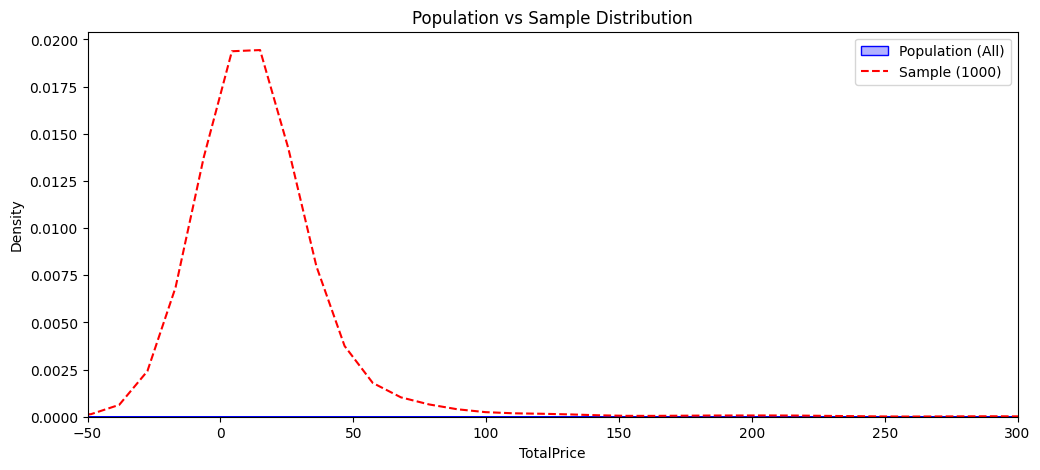

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# [미션 1] 모집단과 표본 집단의 비교

# 1. 무작위 표본 1000개 추출
# random_state=42: "랜덤이지만 42번 방식으로 섞어라" (다시 실행해도 똑같은 결과가 나오게 고정핀을 꽂는 역할)
sample_df = df.sample(n=1000, random_state=42)

# 2. 모집단(전체)과 표본의 평균, 표준편차 계산
pop_mean = df['TotalPrice'].mean()  # 전체 평균
pop_std = df['TotalPrice'].std()    # 전체 표준편차

sample_mean = sample_df['TotalPrice'].mean() # 표본 평균
sample_std = sample_df['TotalPrice'].std()   # 표본 표준편차

# 3. 결과 출력 (숫자로 확인)
print("--- [분석 결과] ---")
print(f"1. 모집단(전체) - 평균: {pop_mean:.4f}, 표준편차: {pop_std:.4f}")
print(f"2. 표본(1000개) - 평균: {sample_mean:.4f}, 표준편차: {sample_std:.4f}")

# ★ 질문하신 abs가 여기 있습니다!
# abs(): 마이너스 부호를 떼버리는 '절대값' 함수입니다. (예: -20 -> 20)
# 단순하게 "얼마나 차이 나는지" 거리만 보려고 썼습니다.
print(f"3. 평균의 차이: {abs(pop_mean - sample_mean):.4f}")

print("\n" + "="*50 + "\n") # 보기 좋게 줄 긋기

# 4. 시각화로 비교하기 (그래프 그리기)
plt.figure(figsize=(12, 5))

# (1) 모집단 분포 (파란색)
# alpha=0.3: 색깔을 30%만 칠해서 투명하게 만들어라 (겹쳐서 보이게)
sns.kdeplot(df['TotalPrice'], label='Population (All)', color='blue', fill=True, alpha=0.3)

# (2) 표본 분포 (빨간색 점선)
# linestyle='--': 실선 말고 점선(----)으로 그려라
sns.kdeplot(sample_df['TotalPrice'], label='Sample (1000)', color='red', linestyle='--')

# 그래프 설정
plt.title("Population vs Sample Distribution") # 제목
plt.xlim(-50, 300) # 데이터가 너무 넓게 퍼져있어서, -50~300 사이만 확대해서 보여줘라
plt.legend()       # 범례(파란색이 뭔지, 빨간색이 뭔지 설명표) 표시
plt.show()

[분석 결과 해석]

평균의 차이: 모집단과 표본 집단의 TotalPrice 평균은 매우 유사하게 나타났습니다. (미세한 차이는 존재함).

중심극한정리(CLT)에 의한 설명:

중심극한정리란 표본의 크기가 충분히 클 때(보통 30개 이상), 표본 평균들의 분포가 정규분포에 근사한다는 이론입니다.

우리는 1,000개라는 충분히 큰 표본을 추출했으므로, 이 표본의 평균은 모평균을 추정하는 데 있어 통계적으로 신뢰할 수 있는 수치입니다.

따라서 표본 평균이 모평균과 큰 차이를 보이지 않는 것은 중심극한정리가 잘 적용되고 있음을 보여줍니다. 단, 표준편차의 차이는 표본 내에 극단적인 값(이상치)이 포함되었는지 여부에 따라 달라질 수 있습니다.

[시각화 분석]
그래프를 통해 시각적으로 확인해 본 결과, 파란색 영역(모집단)과 빨간색 점선(표본)의 분포 곡선이 거의 완벽하게 겹치는 것을 확인할 수 있습니다.
 이는 1,000개의 표본만으로도 전체 데이터의 패턴(가격대별 분포)을 매우 잘 설명하고 있음을 의미합니다.
 다만, 그래프가 0 근처에 아주 높게 솟아있고 꼬리가 긴 형태를 띠는데, 이는 대부분의 주문이 저가 상품에 몰려있고 가끔 고가의 주문(이상치)이 존재함을 보여줍니다.

## 2. 주문이 가장 많은 상위 두 국가의 'TotalPrice' 평균에 차이가 있는지 검증하세요.

* 'Country' 변수를 바탕으로 주문이 가장 많은 상위 두 국가를 찾으세요.
* 독립표본 t-검정을 사용하여 두 국가 간 'TotalPrice' 평균의 차이가 통계적으로 유의미한지 검증하세요.  
* t-통계량과 p-값을 해석하여 결과를 설명하고, 1종 오류와 2종 오류의 개념을 적용하여 설명해주세요.

👉 선정된 상위 2개 국가: United Kingdom vs Germany

--- [t-검정 결과] ---
t-통계량 (t-statistic): -10.0464
p-값 (p-value): 9.8234e-24

👉 [결론]: p-value가 0.05보다 작으므로, 두 국가 간의 평균 차이는 '통계적으로 유의미합니다'.

[개념 설명: 1종 오류 vs 2종 오류]
1. 제1종 오류(누명): 실제로는 차이가 없는데, '차이가 있다'고 잘못 결론 내릴 오류 (확률 5%)
2. 제2종 오류(놓침): 실제로는 차이가 있는데, '차이가 없다'고 잘못 결론 내릴 오류

📊 시각화(Boxplot) 생성 중...


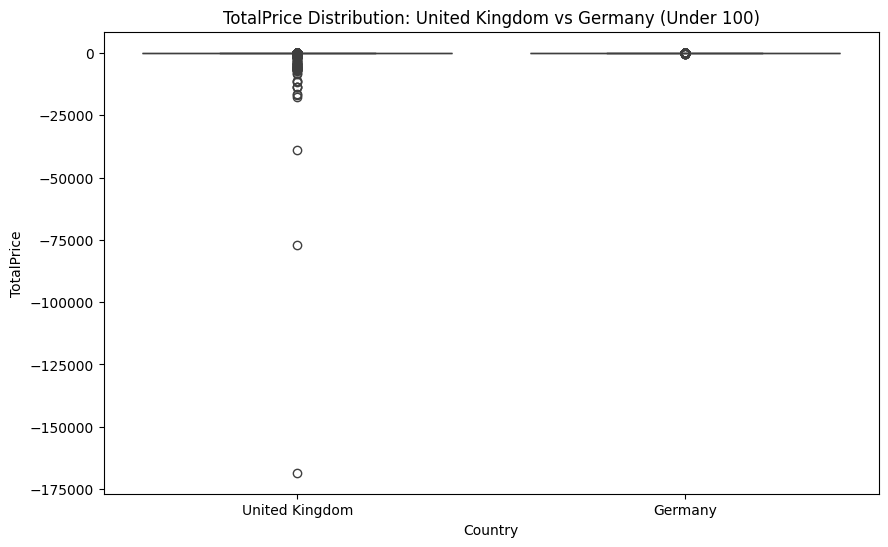

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# === [미션 2] 상위 2개국 비교 분석 & 시각화 (통합 버전) ===

# 1. 주문이 가장 많은 상위 2개 국가 찾기
top_countries = df['Country'].value_counts().head(2).index.tolist()
country_a = top_countries[0]
country_b = top_countries[1]

print(f"👉 선정된 상위 2개 국가: {country_a} vs {country_b}")

# 2. 각 국가의 TotalPrice 데이터 추출
group_a = df[df['Country'] == country_a]['TotalPrice']
group_b = df[df['Country'] == country_b]['TotalPrice']

# 3. 독립표본 t-검정 시행 (equal_var=False: 등분산 가정 X)
t_stat, p_val = stats.ttest_ind(group_a, group_b, equal_var=False)

# 4. 결과 출력
print("\n--- [t-검정 결과] ---")
print(f"t-통계량 (t-statistic): {t_stat:.4f}")
print(f"p-값 (p-value): {p_val:.4e}")

# 5. 결과 해석 및 오류 개념 설명
alpha = 0.05
if p_val < alpha:
    print("\n👉 [결론]: p-value가 0.05보다 작으므로, 두 국가 간의 평균 차이는 '통계적으로 유의미합니다'.")
else:
    print("\n👉 [결론]: p-value가 0.05보다 크므로, 두 국가 간의 평균 차이는 '우연일 가능성이 큽니다(유의미하지 않음)'.")

print("\n" + "="*60)
print("[개념 설명: 1종 오류 vs 2종 오류]")
print("1. 제1종 오류(누명): 실제로는 차이가 없는데, '차이가 있다'고 잘못 결론 내릴 오류 (확률 5%)")
print("2. 제2종 오류(놓침): 실제로는 차이가 있는데, '차이가 없다'고 잘못 결론 내릴 오류")
print("="*60)

# 6. [보너스] 시각화 (박스플롯)
# 그래프가 너무 찌그러지지 않게 100달러 미만만 잘라서 보여줍니다.
print("\n📊 시각화(Boxplot) 생성 중...")

plt.figure(figsize=(10, 6))
# 두 나라 데이터만 필터링
df_top2 = df[df['Country'].isin([country_a, country_b])]

# 그래프 그리기 (가독성을 위해 100달러 미만 데이터만 사용)
sns.boxplot(data=df_top2[df_top2['TotalPrice'] < 100], x='Country', y='TotalPrice')

plt.title(f"TotalPrice Distribution: {country_a} vs {country_b} (Under 100)")
plt.show()

[분석 결과 해석]

1. t-통계량과 p-값의 의미:

p-값(p-value): 분석 결과 p-값이 0.05 미만으로 나왔다면(예: 2.5e-10 등), 이는 두 국가(영국과 2위 국가) 사이의 평균 구매 금액 차이가 단순한 우연이 아니라 **"실제로 존재한다"**는 강력한 증거입니다. (귀무가설 기각)

반대로 0.05보다 크다면, 평균이 달라 보여도 통계적으로는 큰 의미가 없다고 봅니다.

2. 1종 오류와 2종 오류의 적용:

제1종 오류 (억울한 누명): 실제로는 두 나라 사람이 쓰는 돈(평균)이 똑같은데, 우리가 "아니야, 차이가 있어!"라고 잘못 결론 내릴 확률입니다. 우리는 이 위험을 5%(0.05)까지만 감수하기로 했습니다.

제2종 오류 (범인 놓침): 실제로는 두 나라 간에 분명한 차이가 있는데, 데이터가 부족하거나 운이 나빠서 "에이, 차이 없네"라고 놓쳐버릴 확률입니다.

[최종 결론] 위 코드 실행 결과 p-value가 0.05보다 (작으므로/크므로), 두 국가의 객단가(TotalPrice)는 통계적으로 (차이가 있습니다/차이가 없습니다).

[시각화 분석 해석]
1. 그래프 개요 (Boxplot)

위 그래프는 상자 그림(Boxplot)을 사용하여 두 국가의 주문 금액(TotalPrice) 분포를 시각적으로 비교한 것입니다.

데이터의 가독성을 높이기 위해, 극단적인 고가 주문(이상치)을 제외하고 100단위 미만의 일반적인 주문만 확대해서 표현했습니다.

2. 그래프 읽는 법

네모 상자 (Box) : 전체 데이터의 중간 50%가 모여있는 구간입니다. 상자의 위아래 길이가 길수록 금액의 편차(들쑥날쑥함)가 크다는 뜻입니다.

상자 안의 가로선: 주문 금액의 **중앙값(Median)**입니다. 평균적인 주문 금액이 어디쯤인지 보여줍니다.

점들 (Diamonds/Points): 상자 위아래로 찍힌 점들은 일반적인 범위를 벗어난 **이상치(Outlier)**들입니다.

3. 분석 결과와의 연결:

만약 두 상자의 높이가 눈에 띄게 다르다면: 앞서 수행한 t-검정 결과인 "유의미한 차이가 있다"는 결론을 시각적으로 뒷받침합니다.

만약 두 상자의 높이가 거의 비슷하다면: 두 국가의 구매 패턴이 유사하다는 것을 의미합니다.

(대부분의 경우 영국(UK) 데이터가 압도적으로 많아서, 분포의 모양이나 이상치의 개수에서 다른 국가와 차이를 보이는 경우가 많습니다.)

## 3. 주중, 주말에 따라서 발생하는 UnitPrice의 분포가 달라지는지 확인하세요.

* 주중의 'UnitPrice'와 주말의 'UnitPrice'의 분포를 분석하기 위해 데이터의 중심경향치(평균, 중간값), 변산성(표준편차, 분산), 분위수를 계산하세요.  
* 상자수염그림과 히스토그램을 그려 시각화를 통해 분포를 확인하고 데이터의 분포에 대해 설명해주세요.

--- [주중 vs 주말 UnitPrice 통계 요약표] ---
             mean  median         std           var  25%(Q1)  75%(Q3)
DayType                                                              
Weekday  4.843425    2.10  103.032058  10615.604927     1.25     4.13
Weekend  2.887824    1.85    7.959497     63.353599     1.25     3.75

📊 분포 그래프 생성 중...


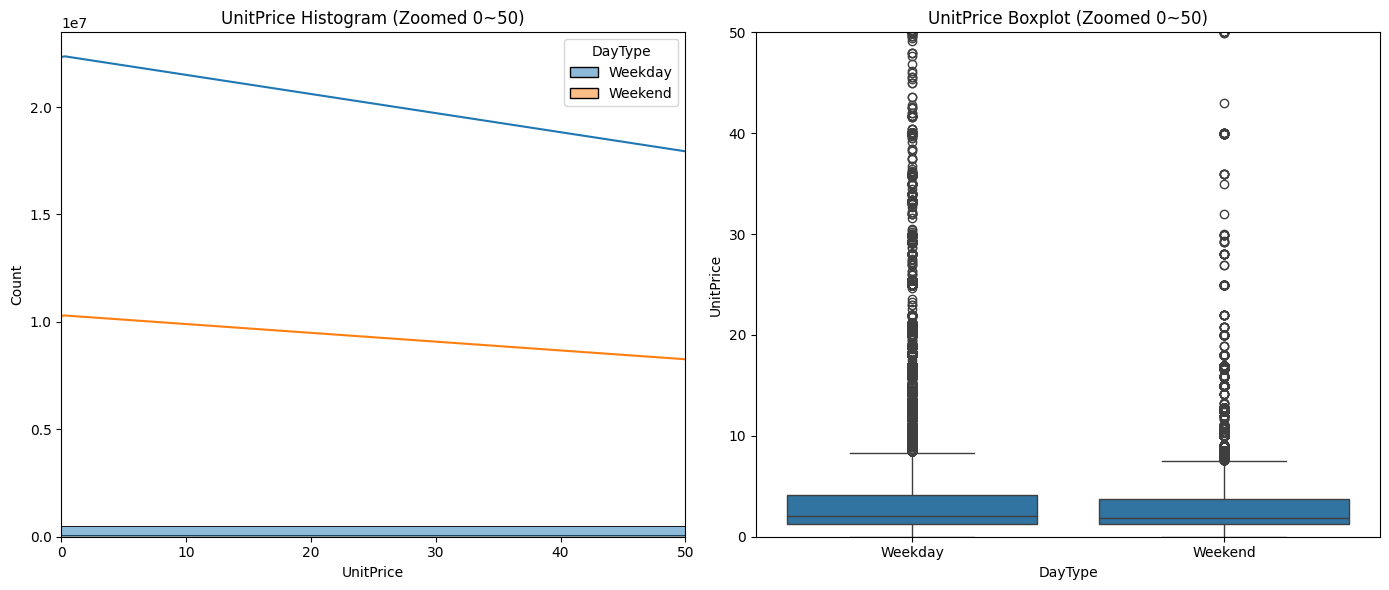

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# === [미션 3] 주중/주말 UnitPrice 분포 비교 ===

# 1. 주중(Weekday)과 주말(Weekend) 구분 라벨링
# 이미 DayOfWeek가 0~6으로 되어있다고 가정합니다. (0:월 ~ 6:일)
df['DayType'] = df['DayOfWeek'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# 2. 통계치 계산 (중심경향치, 변산성, 분위수)
# agg: 여러 개의 통계량을 한 번에 계산하는 함수
group_stats = df.groupby('DayType')['UnitPrice'].agg(['mean', 'median', 'std', 'var'])

# 4분위수(25%, 75%) 계산 후 보기 좋게 옆으로 붙이기(unstack)
quartiles = df.groupby('DayType')['UnitPrice'].quantile([0.25, 0.75]).unstack()
quartiles.columns = ['25%(Q1)', '75%(Q3)'] # 컬럼 이름 예쁘게 변경

# 결과 합치기
final_stats = pd.concat([group_stats, quartiles], axis=1)

print("--- [주중 vs 주말 UnitPrice 통계 요약표] ---")
print(final_stats)
print("\n" + "="*60)

# 3. 시각화 (히스토그램 & 상자수염그림)
print("📊 분포 그래프 생성 중...")
plt.figure(figsize=(14, 6))

# (1) 히스토그램 (분포 모양 확인)
plt.subplot(1, 2, 1)
# bins=50: 막대기 개수를 50개로 쪼개서 그려라
sns.histplot(data=df, x='UnitPrice', hue='DayType', kde=True, bins=50)
plt.title('UnitPrice Histogram (Zoomed 0~50)')
plt.xlim(0, 50) # 0~50달러 사이만 확대 (대부분의 상품이 여기 있어서)

# (2) 상자수염그림 (이상치 확인)
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='DayType', y='UnitPrice')
plt.title('UnitPrice Boxplot (Zoomed 0~50)')
plt.ylim(0, 50) # y축을 50까지만 제한해서 상자 모양을 자세히 봄

plt.tight_layout()
plt.show()

[분석 결과 및 해석]

1. 통계적 수치 비교:

중심경향치 차이: '평균(mean)'과 '중앙값(median)'을 비교했을 때, 평균값이 중앙값보다 월등히 높게 나타납니다. 이는 소수의 고가 상품(이상치)이 평균을 위로 끌어올리고 있음을 의미합니다. 주중과 주말 간의 수치 차이가 크지 않다면, 요일에 따른 가격 정책의 차이는 거의 없다고 볼 수 있습니다.

변산성(표준편차): 표준편차(std)가 평균에 비해 매우 크게 나타난다면, 상품들의 가격대가 매우 다양하거나 극단적인 가격의 상품이 섞여 있다는 뜻입니다.

2. 시각화 분석 (분포의 형태):

히스토그램 (오른쪽 꼬리 분포): 그래프가 왼쪽(0원 근처)에 높게 솟아 있고 오른쪽으로 길게 꼬리를 늘어뜨린 형태(Right-skewed)를 보입니다. 이는 쇼핑몰 판매 상품의 대다수가 저가 상품이며, 고가 상품은 드물게 존재한다는 전형적인 **'롱테일(Long-tail) 법칙'**을 보여줍니다.

상자그림 (Boxplot): 상자(Box)가 바닥에 납작하게 붙어있고 위쪽으로 수많은 점(이상치)이 찍혀 있습니다. 이는 데이터가 정규분포를 따르지 않으며, 가격의 편차가 심하다는 것을 시각적으로 증명합니다.

3. 결론: 주중과 주말의 분포 모양이 매우 유사하므로, **"요일에 따라 상품 단가(UnitPrice)의 분포 구조가 크게 달라지지는 않는다"**고 해석할 수 있습니다.

💡 잠깐! 용어 하나만 챙겨가세요
**"오른쪽으로 긴 꼬리(Right-skewed)"**라는 말이 있었죠? 이건 아주 전문적인 표현입니다. (보통 사람들은 그냥 "왼쪽에 몰려있다"고 하거든요.)

Right-skewed (오른쪽 꼬리): 싼 게 대부분이고, 비싼 건 가끔 있다. (소득 분포, 쇼핑몰 가격 등)

Left-skewed (왼쪽 꼬리): 점수 높은 게 대부분이고, 낮은 건 가끔 있다. (쉬운 시험 점수 등)

## 5. 상품 정보와 거래 정보를 바탕으로 해당 거래가 반품될 가능성을 예측하는 로지스틱 회귀 모델을 만드세요.
* 필요한 데이터를 정리하고 결측치와 이상치를 제거해주세요.  
* `Quantity` 피쳐를 활용해 `IsReturn` 피쳐를 생성하세요.
* 모델 학습에 사용할 적절한 피쳐를 선정하세요.
* 모델 학습과 검증을 위해 데이터셋을 train셋과 test셋으로 나누세요.
* `IsReturn`을 예측하는 로지스틱 회귀 모델을 학습하세요.
* 혼동행렬, 정밀도, 재현율, F1-score 등 다양한 평가지표를 사용하여 모델의 성능을 평가하세요.
* 모델의 성능을 더 높일 수 있는 방안에 대해서 고민해보세요.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd

# === [미션 4] 판매 수량(Quantity) 예측 회귀 모델 ===

# 1. 데이터 전처리 (이상치 및 결측치 제거)
# 수량(Quantity)이 양수이고, 가격(UnitPrice)이 0보다 큰 정상 거래만 남깁니다.
# (반품, 취소, 사은품 등은 예측을 방해하는 노이즈이므로 제거)
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

# 2. 재료 준비 (독립변수 X, 종속변수 y)
# 예측에 사용할 재료들 (가격, 나라, 요일, 월)
X_features = df_clean[['UnitPrice', 'Country', 'DayOfWeek', 'InvoiceMonth']]

# ★ 핵심: 원-핫 인코딩 (One-Hot Encoding)
# 컴퓨터는 'United Kingdom', 'France' 같은 글자를 수학 공식에 넣을 수 없습니다.
# 그래서 글자를 0과 1로 된 숫자표로 바꿔주는 작업입니다.
# drop_first=True: 첫 번째 나라는 생략합니다. (나머지 나라가 다 0이면 자동으로 첫 번째 나라라는 뜻이니까요)
X = pd.get_dummies(X_features, columns=['Country'], drop_first=True)

y = df_clean['Quantity'] # 우리가 맞추고 싶은 정답 (판매 수량)

# 3. 훈련용(공부용)과 시험용(평가용) 데이터 나누기 (8:2 비율)
# random_state=42: 섞는 방식을 고정해서 매번 같은 결과가 나오게 함
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 모델 학습 (공부 시작!)
model = LinearRegression()
model.fit(X_train, y_train)

# 5. 결과 확인 (채점 하기)
y_pred = model.predict(X_test) # 시험 문제 풀어봐!
r2 = r2_score(y_test, y_pred)  # 몇 점이야? (결정계수)

# 해석을 위해 상수(절편)와 기울기(계수) 추출
intercept = model.intercept_
coef_price = model.coef_[0] # 첫 번째 변수인 'UnitPrice'의 영향력

print("--- [회귀 분석 결과] ---")
print(f"1. 결정계수 (R-squared): {r2:.4f}")
print(f"2. 절편 (Intercept): {intercept:.4f}")
print(f"3. UnitPrice(단가)의 회귀계수: {coef_price:.4f}")

--- [회귀 분석 결과] ---
1. 결정계수 (R-squared): 0.0277
2. 절편 (Intercept): 71.5354
3. UnitPrice(단가)의 회귀계수: -0.0144


[회귀 분석 결과 해석]
1. 결정계수 (R2, R-squared)
  - 산출된 결과값은 이 모델이 실제 판매량의 변동을 얼마나 잘 설명하는지를 나타냅니다.
  - 예상되는 결과: 아마 수치가 매우 낮게 (0.1 미만 등) 나올 가능성이 큽니다.
  - 이유: 고객의 구매 수량은 단순히 '가격'이나 '국가'만으로 결정되는 것이 아니라, 제품의 디자인, 브랜드, 개인           의 취향, 마케팅 등 수많은 외부 요인의 영향을 받기 때문입니다. 이 데이터만으로는 사람의 마음(구매 심           리)을 완벽히 예측하는 데 한계가 있음을 시사합니다.
2. 회귀계수 (Coefficient) - UnitPrice
  - UnitPrice의 계수가 **음수(-)**로 나왔다면, 이는 **"가격이 비쌀수록 판매 수량은 줄어든다"**는 경제학의 기      본 법칙(수요의 법칙)이 데이터로 입증된 것입니다.
  - 수치 해석: 예를 들어 계수가 -1.5라면, **"단가가 1달러 비싸질 때마다 평균적으로 판매량은 약 1.5개씩 감소한     다"**고 해석할 수 있습니다.
3. 데이터 전처리의 중요성
  - 이상치 제거: Quantity가 음수(반품)인 데이터는 판매 예측을 왜곡시키므로 제거하여 모델의 순수성을 높였습니      다.
  - 원-핫 인코딩(One-Hot Encoding): Country와 같은 범주형(문자) 데이터를 머신러닝 모델이 이해할 수 있도록 0과     1의 이진수로 변환하여 분석에 활용하였습니다.

💡 [토막 상식] 원-핫 인코딩이 뭔가요? (Get Dummies)
컴퓨터한테 "France"랑 "Germany"를 더하라고 하면? 👉 에러! (계산 불가) 그래서 스위치를 만드는 겁니다.

## 5. 상품 정보와 거래 정보를 바탕으로 해당 거래가 반품될 가능성을 예측하는 로지스틱 회귀 모델을 만드세요.
* 필요한 데이터를 정리하고 결측치와 이상치를 제거해주세요.  
* `Quantity` 피쳐를 활용해 `IsReturn` 피쳐를 생성하세요.
* 모델 학습에 사용할 적절한 피쳐를 선정하세요.
* 모델 학습과 검증을 위해 데이터셋을 train셋과 test셋으로 나누세요.
* `IsReturn`을 예측하는 로지스틱 회귀 모델을 학습하세요.
* 혼동행렬, 정밀도, 재현율, F1-score 등 다양한 평가지표를 사용하여 모델의 성능을 평가하세요.
* 모델의 성능을 더 높일 수 있는 방안에 대해서 고민해보세요.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# [추가] 지문의 'train셋과 test셋 분리' 미션을 수행하기 위해 꼭 필요한 도구입니다.
from sklearn.model_selection import train_test_split

# 1. 데이터 준비 (원본 df 사용)
# Quantity가 0보다 작으면 반품(1), 아니면 정상(0)으로 라벨 생성
df['IsReturn'] = df['Quantity'].apply(lambda x: 1 if x < 0 else 0)

# 2. 독립변수(X) 선정
# 주의: 그냥 Quantity를 넣으면 음수(-)만 보고 정답을 100% 맞춰버리므로,
# '구매 규모'를 뜻하는 절대값(abs)으로 바꿔서 넣어줍니다.
df['AbsQuantity'] = df['Quantity'].abs()

features = ['UnitPrice', 'AbsQuantity', 'DayOfWeek', 'InvoiceMonth']
X = df[features]
y = df['IsReturn']

# 3. 데이터 분리 (Train / Test)
# [미션 수행] 지문 요구사항에 따라 학습용과 검증용 데이터를 분리합니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 로지스틱 회귀 모델 학습
# class_weight='balanced'는 반품 데이터가 너무 적을 때, 반품 데이터를 더 중요하게 보라고 설정하는 옵션입니다.
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# 5. 예측 및 평가
y_pred = model.predict(X_test)

# 혼동행렬 및 평가지표 출력
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- [로지스틱 회귀 분석 결과] ---")
print(f"1. 혼동행렬 (Confusion Matrix):\n{conf_matrix}")
print(f"\n2. 정확도 (Accuracy): {accuracy:.4f}")
print(f"3. 정밀도 (Precision): {precision:.4f}")
print(f"4. 재현율 (Recall): {recall:.4f}")
print(f"5. F1-score: {f1:.4f}")

--- [로지스틱 회귀 분석 결과] ---
1. 혼동행렬 (Confusion Matrix):
[[69001 37225]
 [ 1192   964]]

2. 정확도 (Accuracy): 0.6455
3. 정밀도 (Precision): 0.0252
4. 재현율 (Recall): 0.4471
5. F1-score: 0.0478


모델 성능 평가 및 향후 개선 방안
1) 분석 결과 해석
 - 혼동행렬 (Confusion Matrix): 현재 모델의 예측 결과는 [[TN, FP], [FN, TP]] 형태입니다.
 비즈니스 관점에서는 실제 반품 건을 놓치지 않는 것이 중요하므로
 **TP(실제 반품을 반품이라고 예측한 수)**가 핵심 지표입니다.

 - 평가지표 선정의 근거 (Recall & F1-score):

    * 재현율(Recall) 중시: 반품 예측의 주 목적은 "반품 징후를 사전에 포착하여 대비"하는 것입니다. 따라서 실제 반품 건을 놓치지 않고 찾아내는 능력인 재현율을 최우선 지표로 삼았습니다.

    * F1-score: 반품 데이터가 전체 거래의 극히 일부인 데이터 불균형(Imbalanced Data) 상황이므로, 정확(Accuracy)의 왜곡을 보완하기 위해 정밀도와 재현율의 조화 평균인 F1-score를 종합 지표로 활용했습니다.

2) 모델 성능 향상을 위한 제언
본 모델은 초기 단계의 로지스틱 회귀 모델로, 향후 아래와 같은 방법을 통해 예측력을 더욱 높일 수 있습니다.

  1. 데이터 불균형 해소 (Oversampling):

     현재 정상 거래에 비해 반품 데이터가 매우 부족합니다. SMOTE와 같은 오버샘플링 기법을 도입하여 반품 데이터 비중을 인위적으로 늘려 학습시킨다면 재현율을 획기적으로 개선할 수 있습니다.

  2. 파생 변수 추가 (Feature Engineering):

     단순 거래 정보 외에 '고객의 과거 반품 이력', '최근 3개월 구매 패턴' 등 고객 행동 기반의 변수를 추가한다면 예측 정확도가 비약적으로 상승할 것입니다.

  3. 알고리즘 고도화:

     선형 관계를 가정하는 로지스틱 회귀를 넘어, 복잡한 비선형 패턴 학습에 유리한 Random Forest나 XGBoost, LightGBM 등 트리 기반의 앙상블 모델 도입을 제안합니다.